# nb15 — RNA → Protein Prediction

Train a bottleneck MLP to predict all protein abundances from full RNA input.
Two imputation strategies × three sparsity regimes = 6 arms.

| Arm | Imputation | Sparsity | Name |
|-----|-----------|----------|------|
| A1 | Mean (train only) | L1 λ=1e-3 | `mean_l1_1e3` |
| A2 | Mean (train only) | L1 λ=1e-4 | `mean_l1_1e4` |
| A3 | Mean (train only) | Top-k k=32 | `mean_topk` |
| B1 | Masked loss | L1 λ=1e-3 | `masked_l1_1e3` |
| B2 | Masked loss | L1 λ=1e-4 | `masked_l1_1e4` |
| B3 | Masked loss | Top-k k=32 | `masked_topk` |

Architecture: RNA (full) → Dropout → Linear(rna_dim, 512) → BN → ReLU → Linear(512, 256) → BN → [sparsity] → Linear(256, protein_dim)

## Environment setup

In [1]:
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q torch-geometric rdkit
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/multiomics_project')
else:
    BASE_PATH = Path('..')

print(f"Running on {'Colab' if IN_COLAB else 'local'} | BASE_PATH = {BASE_PATH}")

Mounted at /content/drive
Running on Colab | BASE_PATH = /content/drive/MyDrive/multiomics_project


## GPU check

In [2]:
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if DEVICE.type == 'cpu':
    print('WARNING: no GPU detected — Runtime > Change runtime type > GPU')

Device: cuda


## Imports and config

In [3]:
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GroupShuffleSplit
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

In [4]:
DATA_DIR      = BASE_PATH / 'data' / 'GDSC2'
PROCESSED_DIR = BASE_PATH / 'data' / 'processed'
SPLITS_DIR    = BASE_PATH / 'data' / 'splits'
RESULTS_DIR   = BASE_PATH / 'results' / 'rna_to_protein'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / 'checkpoints').mkdir(exist_ok=True)

COL_CELLOSAURUS = 'cellosaurus_id'
COL_DRUG        = 'drug_name'
COL_TISSUE      = 'tissue'

VALIDATION_RATIO = 0.1
RANDOM_STATE     = 42
BATCH_SIZE       = 32   # small — each sample is (rna_dim,) → (protein_dim,), large tensors
NUM_EPOCHS       = 100
PATIENCE         = 15
INPUT_DROPOUT    = 0.3  # dropout on raw RNA input before first linear
HIDDEN_DROPOUT   = 0.3  # dropout in encoder MLP
EMBED_DIM        = 256  # bottleneck dimension
TOPK_K           = 32   # number of active bottleneck units for top-k arms

## Load data

In [5]:
pairs = pd.read_parquet(PROCESSED_DIR / 'response_pairs.parquet')

with open(SPLITS_DIR / 'splits.json') as f:
    folds = json.load(f)

print(f'{len(pairs):,} response pairs loaded')

176,197 response pairs loaded


In [6]:
rna     = pd.read_csv(DATA_DIR / 'gene_expression.csv',  index_col=0)
protein = pd.read_csv(DATA_DIR / 'proteomics.csv',        index_col=0)

# Deduplicate immediately — duplicate cellosaurus_id rows cause silent mismatches
rna     = rna[~rna.index.duplicated(keep='first')].iloc[:, 1:]
protein = protein[~protein.index.duplicated(keep='first')]
# Do NOT fillna here — we handle NaNs per arm below

print(f'RNA:     {rna.shape[1]:,} genes    x {rna.shape[0]:,} cell lines')
print(f'Protein: {protein.shape[1]:,} proteins x {protein.shape[0]:,} cell lines')
print(f'Protein NaN rate: {protein.isna().mean().mean():.3f}')

RNA:     17,737 genes    x 1,010 cell lines
Protein: 6,692 proteins x 860 cell lines
Protein NaN rate: 0.480


## Cell line split

Use fold 0 LCO cell lines as test set. This notebook has no drug axis —
we work purely at the cell line level (one sample = one cell line).

In [7]:
def get_cell_line_splits(fold_idx: int = 0):
    """Return train/val/test cell line IDs from existing LCO fold.
    Test = LCO test cell lines for this fold.
    Val  = 10% of train cell lines held out by GroupShuffleSplit on tissue.
    """
    fold = folds[fold_idx]

    # LCO test cell lines
    lco_test_pairs = pairs.loc[fold['lco_test']]
    test_cells = set(lco_test_pairs[COL_CELLOSAURUS].unique())

    # Train cell lines = all cell lines not in test
    train_pairs = pairs.loc[fold['train']]
    train_cells_all = list(set(train_pairs[COL_CELLOSAURUS].unique()) - test_cells)

    # Carve validation from train by tissue group
    cell_tissue = (
        train_pairs[[COL_CELLOSAURUS, COL_TISSUE]]
        .drop_duplicates(COL_CELLOSAURUS)
        .set_index(COL_CELLOSAURUS)
    )
    cell_tissue = cell_tissue.loc[cell_tissue.index.isin(train_cells_all)]

    gss = GroupShuffleSplit(n_splits=1, test_size=VALIDATION_RATIO,
                            random_state=RANDOM_STATE)
    tr_idx, va_idx = next(gss.split(
        np.arange(len(cell_tissue)),
        groups=cell_tissue[COL_TISSUE].values,
    ))
    train_cells = list(cell_tissue.index[tr_idx])
    val_cells   = list(cell_tissue.index[va_idx])

    return train_cells, val_cells, list(test_cells)


train_cells, val_cells, test_cells = get_cell_line_splits(fold_idx=0)
print(f'Train cell lines: {len(train_cells):,}')
print(f'Val   cell lines: {len(val_cells):,}')
print(f'Test  cell lines: {len(test_cells):,}')
assert not set(train_cells) & set(test_cells), 'leakage: train/test overlap'
assert not set(val_cells)   & set(test_cells), 'leakage: val/test overlap'

Train cell lines: 603
Val   cell lines: 40
Test  cell lines: 84


## Imputation helpers

Mean imputation: per-protein mean computed on train cell lines only, applied to val/test.
Masked loss: NaNs kept in targets; loss ignores missing positions.

In [57]:
def get_protein_matrices_mean(train_cells, val_cells, test_cells):
    tr = protein.loc[protein.index.isin(train_cells)]
    va = protein.loc[protein.index.isin(val_cells)]
    te = protein.loc[protein.index.isin(test_cells)]

    # Drop proteins with no observed values in train
    train_means = tr.mean(axis=0)
    valid_proteins = train_means.notna()
    tr = tr.loc[:, valid_proteins]
    va = va.loc[:, valid_proteins]
    te = te.loc[:, valid_proteins]
    train_means = train_means[valid_proteins]

    tr = tr.fillna(train_means)
    va = va.fillna(train_means)
    te = te.fillna(train_means)

    return (
        tr.to_numpy(dtype=np.float32),
        va.to_numpy(dtype=np.float32),
        te.to_numpy(dtype=np.float32),
        tr.index.tolist(),
        va.index.tolist(),
        te.index.tolist(),
        tr.columns.tolist(),
    )


def get_protein_matrices_masked(train_cells, val_cells, test_cells):
    tr = protein.loc[protein.index.isin(train_cells)]
    va = protein.loc[protein.index.isin(val_cells)]
    te = protein.loc[protein.index.isin(test_cells)]

    # Drop proteins with no observed values in train
    train_means = tr.mean(axis=0)
    valid_proteins = train_means.notna()
    tr = tr.loc[:, valid_proteins]
    va = va.loc[:, valid_proteins]
    te = te.loc[:, valid_proteins]

    return (
        tr.to_numpy(dtype=np.float32),
        va.to_numpy(dtype=np.float32),
        te.to_numpy(dtype=np.float32),
        tr.index.tolist(),
        va.index.tolist(),
        te.index.tolist(),
        tr.columns.tolist(),
    )


def get_rna_matrices(train_cells, val_cells, test_cells):
    """Return aligned RNA matrices for train/val/test cell lines."""
    tr = rna.loc[rna.index.isin(train_cells)].to_numpy(dtype=np.float32)
    va = rna.loc[rna.index.isin(val_cells)].to_numpy(dtype=np.float32)
    te = rna.loc[rna.index.isin(test_cells)].to_numpy(dtype=np.float32)
    return tr, va, te

In [58]:
# Build RNA matrices (shared across all arms)
rna_tr, rna_va, rna_te = get_rna_matrices(train_cells, val_cells, test_cells)

# Build protein matrices — mean imputation variant
prot_tr_mean, prot_va_mean, prot_te_mean, \
    tr_cells_mean, va_cells_mean, te_cells_mean, protein_cols = \
    get_protein_matrices_mean(train_cells, val_cells, test_cells)

# Build protein matrices — masked variant (NaNs retained)
prot_tr_mask, prot_va_mask, prot_te_mask, \
    tr_cells_mask, va_cells_mask, te_cells_mask, _ = \
    get_protein_matrices_masked(train_cells, val_cells, test_cells)

RNA_DIM     = rna_tr.shape[1]
PROTEIN_DIM = prot_tr_mean.shape[1]

print(f'RNA dim:     {RNA_DIM:,}')
print(f'Protein dim: {PROTEIN_DIM:,}')
print(f'Train cell lines (mean): {rna_tr.shape[0]} | (masked): {prot_tr_mask.shape[0]}')
print(f'Val   cell lines: {rna_va.shape[0]}')
print(f'Test  cell lines: {rna_te.shape[0]}')

RNA dim:     17,737
Protein dim: 6,651
Train cell lines (mean): 603 | (masked): 603
Val   cell lines: 40
Test  cell lines: 84


## DataLoader helpers

In [10]:
def make_dataloader(rna_np: np.ndarray, protein_np: np.ndarray,
                    shuffle: bool) -> DataLoader:
    """Build a DataLoader from RNA and protein numpy arrays.
    For masked arms, protein_np may contain NaNs — converted to nan-filled float tensor.
    """
    rna_t     = torch.from_numpy(rna_np)
    protein_t = torch.from_numpy(protein_np)   # NaNs become float('nan') in tensor
    dataset   = TensorDataset(rna_t, protein_t)
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle, drop_last=shuffle)

## Loss functions

In [11]:
def masked_mse_loss(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """MSE computed only on observed (non-NaN) positions.
    pred, target: (batch, protein_dim)
    """
    mask = ~torch.isnan(target)
    if mask.sum() == 0:
        return torch.tensor(0.0, requires_grad=True, device=pred.device)
    return F.mse_loss(pred[mask], target[mask])


def l1_activity_loss(bottleneck: torch.Tensor) -> torch.Tensor:
    """L1 penalty on bottleneck activations to encourage sparsity."""
    return bottleneck.abs().mean()

## Model architecture

In [12]:
class TopKActivation(nn.Module):
    """Hard sparsity: keep only top-k activations per sample, zero the rest.
    Straight-through estimator for gradients — zeroed units get zero gradient.
    """
    def __init__(self, k: int):
        super().__init__()
        self.k = k

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if not self.training:
            return x  # no masking at eval time — use full representation
        topk_vals, _ = torch.topk(x.abs(), self.k, dim=1)
        threshold = topk_vals[:, -1:]
        mask = (x.abs() >= threshold).float()
        return x * mask


class RNAToProteinMLP(nn.Module):
    """Bottleneck MLP: RNA → sparse 256-d embedding → protein predictions.

    sparsity_mode : 'l1' or 'topk'
    l1_lambda     : weight of L1 activity penalty (only used when sparsity_mode='l1')
    topk_k        : number of active units (only used when sparsity_mode='topk')
    """

    def __init__(self, rna_dim: int, protein_dim: int,
                 embed_dim: int = EMBED_DIM,
                 sparsity_mode: str = 'l1',
                 l1_lambda: float = 1e-3,
                 topk_k: int = TOPK_K,
                 input_dropout: float = INPUT_DROPOUT,
                 hidden_dropout: float = HIDDEN_DROPOUT):
        super().__init__()
        assert sparsity_mode in ('l1', 'topk')
        self.sparsity_mode = sparsity_mode
        self.l1_lambda     = l1_lambda

        # Encoder: RNA → bottleneck
        self.input_drop = nn.Dropout(input_dropout)
        self.fc1        = nn.Linear(rna_dim, 512)
        self.bn1        = nn.BatchNorm1d(512)
        self.drop1      = nn.Dropout(hidden_dropout)
        self.fc2        = nn.Linear(512, embed_dim)
        self.bn2        = nn.BatchNorm1d(embed_dim)

        # Sparsity at bottleneck
        self.topk = TopKActivation(topk_k) if sparsity_mode == 'topk' else None

        # Decoder: bottleneck → protein predictions
        self.decoder = nn.Linear(embed_dim, protein_dim)

    def encode(self, rna: torch.Tensor) -> torch.Tensor:
        """Return bottleneck embedding (before decoder). Used for analysis."""
        x = self.input_drop(rna)
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop1(x)
        x = F.relu(self.bn2(self.fc2(x)))
        return x

    def forward(self, rna: torch.Tensor):
        """Returns (predictions, bottleneck) — bottleneck needed for L1 loss."""
        bottleneck = self.encode(rna)

        if self.sparsity_mode == 'topk':
            bottleneck = self.topk(bottleneck)

        pred = self.decoder(bottleneck)
        return pred, bottleneck


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## Training loop

In [29]:
def fit_rna_to_protein(model: nn.Module,
                        train_loader: DataLoader,
                        val_loader: DataLoader,
                        arm_name: str,
                        use_masked_loss: bool,
                        checkpoint_path: Path,
                        device: torch.device):
    """Train RNA→protein model.
    use_masked_loss: if True, ignore NaN positions in the loss.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=5, factor=0.5
    )

    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_weights  = None
    wait          = 0

    print(f'Training arm: {arm_name} | params: {count_parameters(model):,} | '
          f'sparsity: {model.sparsity_mode} | masked_loss: {use_masked_loss}')

    for epoch in range(NUM_EPOCHS):
        for phase in ['val', 'train']:
            loader       = train_loader if phase == 'train' else val_loader
            phase_device = device if phase == 'train' else torch.device('cpu')
            model.to(phase_device)
            model.train() if phase == 'train' else model.eval()

            batch_losses = []

            for rna_batch, protein_batch in tqdm(loader,
                                                  desc=f'epoch {epoch+1} {phase}',
                                                  leave=False):
                rna_batch     = rna_batch.to(phase_device)
                protein_batch = protein_batch.to(phase_device)

                if phase == 'train':
                    optimizer.zero_grad()
                    pred, bottleneck = model(rna_batch)

                    if use_masked_loss:
                        recon_loss = masked_mse_loss(pred, protein_batch)
                    else:
                        recon_loss = F.mse_loss(pred, protein_batch)

                    if model.sparsity_mode == 'l1':
                        loss = recon_loss + model.l1_lambda * l1_activity_loss(bottleneck)
                    else:
                        loss = recon_loss

                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                else:
                    with torch.no_grad():
                        pred, _ = model(rna_batch)
                        if use_masked_loss:
                            loss = masked_mse_loss(pred, protein_batch)
                        else:
                            loss = F.mse_loss(pred, protein_batch)

                batch_losses.append(loss.item())

            epoch_loss = sum(batch_losses) / len(batch_losses)
            history[f'{phase}_loss'].append(epoch_loss)

            if phase == 'val':
                scheduler.step(epoch_loss)
                print(f'  epoch {epoch+1:>3} | val loss={epoch_loss:.5f}')
                if epoch_loss < best_val_loss:
                    best_val_loss = epoch_loss
                    best_weights  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                    wait = 0
                else:
                    wait += 1
                    if wait >= PATIENCE:
                        print(f'  Early stopping at epoch {epoch+1}')
                        model.load_state_dict(best_weights)
                        torch.save(best_weights, checkpoint_path)
                        print(f'  Best val loss: {best_val_loss:.5f} -> {checkpoint_path}')
                        return model, history

    model.load_state_dict(best_weights)
    torch.save(best_weights, checkpoint_path)
    print(f'  Best val loss: {best_val_loss:.5f} -> {checkpoint_path}')
    return model, history

## Evaluation helpers

In [30]:
def predict_rna_to_protein(model: nn.Module, rna_np: np.ndarray,
                             device: str = 'cpu') -> np.ndarray:
    """Run inference. Returns (n_cells, protein_dim) numpy array."""
    model.to(device)
    model.eval()
    rna_t  = torch.from_numpy(rna_np)
    preds  = []
    with torch.no_grad():
        for i in range(0, rna_t.shape[0], BATCH_SIZE):
            pred, _ = model(rna_t[i:i+BATCH_SIZE].to(device))
            preds.append(pred.cpu())
    return torch.cat(preds).numpy()


def evaluate_rna_to_protein(pred_np: np.ndarray,
                              target_np: np.ndarray,
                              protein_names: list) -> pd.DataFrame:
    """Per-protein Pearson r and R² on held-out cell lines.
    NaN positions in target are excluded per protein.
    Returns a DataFrame with one row per protein.
    """
    rows = []
    for j, pname in enumerate(protein_names):
        y_true = target_np[:, j]
        y_pred = pred_np[:, j]

        # Drop NaN positions in target for this protein
        valid = ~np.isnan(y_true)
        if valid.sum() < 5:
            # Too few observed values — skip
            rows.append({'protein': pname, 'pearson_r': np.nan, 'r2': np.nan, 'n_observed': valid.sum()})
            continue

        r, _  = pearsonr(y_true[valid], y_pred[valid])
        r2    = r2_score(y_true[valid], y_pred[valid])
        rows.append({'protein': pname, 'pearson_r': r, 'r2': r2, 'n_observed': valid.sum()})

    return pd.DataFrame(rows)


def summarise_eval(df: pd.DataFrame, arm_name: str) -> dict:
    """Aggregate per-protein metrics into a summary row."""
    valid = df.dropna(subset=['pearson_r'])
    return {
        'arm':              arm_name,
        'median_pearson_r': round(valid['pearson_r'].median(), 4),
        'mean_pearson_r':   round(valid['pearson_r'].mean(),   4),
        'pct_r_gt_0.1':     round((valid['pearson_r'] > 0.1).mean() * 100, 1),
        'pct_r_gt_0.3':     round((valid['pearson_r'] > 0.3).mean() * 100, 1),
        'pct_r_gt_0.5':     round((valid['pearson_r'] > 0.5).mean() * 100, 1),
        'median_r2':        round(valid['r2'].median(), 4),
        'n_proteins':       len(valid),
    }

## Build shared dataloaders

Mean-imputed and masked variants share the same RNA matrices but differ in protein targets.

In [59]:
# Mean imputation dataloaders (shared by arms A1, A2, A3)
mean_train_loader = make_dataloader(rna_tr, prot_tr_mean, shuffle=True)
mean_val_loader   = make_dataloader(rna_va, prot_va_mean, shuffle=False)

# Masked dataloaders (shared by arms B1, B2, B3)
mask_train_loader = make_dataloader(rna_tr, prot_tr_mask, shuffle=True)
mask_val_loader   = make_dataloader(rna_va, prot_va_mask, shuffle=False)

print('Mean imputation:')
print(f'  train batches: {len(mean_train_loader)} | val batches: {len(mean_val_loader)}')
print('Masked:')
print(f'  train batches: {len(mask_train_loader)} | val batches: {len(mask_val_loader)}')

Mean imputation:
  train batches: 18 | val batches: 2
Masked:
  train batches: 18 | val batches: 2


---
## Arm A1 — Mean imputation | L1 λ=1e-3

In [41]:
armA1_model = RNAToProteinMLP(
    rna_dim=RNA_DIM, protein_dim=PROTEIN_DIM,
    sparsity_mode='l1', l1_lambda=1e-3,
)
print(f'Arm A1 parameters: {count_parameters(armA1_model):,}')

Arm A1 parameters: 10,924,027


In [42]:
armA1_model

RNAToProteinMLP(
  (input_drop): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=17737, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (decoder): Linear(in_features=256, out_features=6651, bias=True)
)

In [43]:
for rna_batch_t, protein_batch_t in mean_train_loader:
    print(rna_batch_t.shape, protein_batch_t.shape)
    break  # just show one batch

torch.Size([32, 17737]) torch.Size([32, 6651])


In [44]:
rna_batch_t

tensor([[ 8.8351,  2.7683,  9.3253,  ...,  9.0954,  3.2707,  7.5778],
        [ 7.4850,  2.9272,  9.7689,  ...,  9.2902,  3.4914,  7.4105],
        [ 5.8789,  2.7389,  9.9247,  ...,  9.4470,  3.4361,  7.1731],
        ...,
        [ 6.2901,  2.7929,  9.8095,  ...,  8.3653,  3.7445,  7.1316],
        [ 7.9879,  2.6655, 10.7793,  ...,  9.4417,  3.1920,  7.5526],
        [ 9.1273,  2.6194, 10.7686,  ...,  9.1273,  3.1589,  7.7336]])

In [45]:
print("RNA NaNs:", np.isnan(rna_tr).sum())
print("RNA infs:", np.isinf(rna_tr).sum())
print("RNA min:", rna_tr.min(), "max:", rna_tr.max())
print("Protein NaNs:", np.isnan(prot_tr_mean).sum())
print("Protein infs:", np.isinf(prot_tr_mean).sum())
print("Protein min:", prot_tr_mean.min(), "max:", prot_tr_mean.max())

RNA NaNs: 0
RNA infs: 0
RNA min: 2.1290445 max: 13.9297285
Protein NaNs: 0
Protein infs: 0
Protein min: -3.3694928 max: 15.503639


In [46]:
armA1_model, armA1_history = fit_rna_to_protein(
    model=armA1_model,
    train_loader=mean_train_loader,
    val_loader=mean_val_loader,
    arm_name='mean_l1_1e3',
    use_masked_loss=False,
    checkpoint_path=RESULTS_DIR / 'checkpoints' / 'armA1_mean_l1_1e3.pt',
    device=DEVICE,
)

Training arm: mean_l1_1e3 | params: 10,924,027 | sparsity: l1 | masked_loss: False


epoch 1 val:   0%|          | 0/2 [00:00<?, ?it/s]

  epoch   1 | val loss=16.09090


epoch 1 train:   0%|          | 0/18 [00:00<?, ?it/s]

epoch 2 val:   0%|          | 0/2 [00:00<?, ?it/s]

...

epoch 21 val:   0%|          | 0/2 [00:00<?, ?it/s]

  epoch  21 | val loss=0.62351


epoch 21 train:   0%|          | 0/18 [00:00<?, ?it/s]

epoch 22 val:   0%|          | 0/2 [00:00<?, ?it/s]

  epoch  22 | val loss=0.62650
  Early stopping at epoch 22
  Best val loss: 0.50183 -> /content/drive/MyDrive/multiomics_project/results/rna_to_protein/checkpoints/armA1_mean_l1_1e3.pt


In [47]:
armA1_pred    = predict_rna_to_protein(armA1_model, rna_te)
armA1_eval_df = evaluate_rna_to_protein(armA1_pred, prot_te_mean, protein_cols)
armA1_summary = summarise_eval(armA1_eval_df, 'mean_l1_1e3')
print(armA1_summary)
armA1_eval_df.to_csv(RESULTS_DIR / 'armA1_per_protein.csv', index=False)

{'arm': 'mean_l1_1e3', 'median_pearson_r': -0.0175, 'mean_pearson_r': np.float32(-0.0136), 'pct_r_gt_0.1': np.float64(16.4), 'pct_r_gt_0.3': np.float64(0.2), 'pct_r_gt_0.5': np.float64(0.0), 'median_r2': -0.8698, 'n_proteins': 6437}


---
## Arm A2 — Mean imputation | L1 λ=1e-4

In [48]:
armA2_model = RNAToProteinMLP(
    rna_dim=RNA_DIM, protein_dim=PROTEIN_DIM,
    sparsity_mode='l1', l1_lambda=1e-4,
)
print(f'Arm A2 parameters: {count_parameters(armA2_model):,}')

Arm A2 parameters: 10,924,027


In [49]:
armA2_model, armA2_history = fit_rna_to_protein(
    model=armA2_model,
    train_loader=mean_train_loader,
    val_loader=mean_val_loader,
    arm_name='mean_l1_1e4',
    use_masked_loss=False,
    checkpoint_path=RESULTS_DIR / 'checkpoints' / 'armA2_mean_l1_1e4.pt',
    device=DEVICE,
)

Training arm: mean_l1_1e4 | params: 10,924,027 | sparsity: l1 | masked_loss: False


epoch 1 val:   0%|          | 0/2 [00:00<?, ?it/s]

  epoch   1 | val loss=16.34767


epoch 1 train:   0%|          | 0/18 [00:00<?, ?it/s]

epoch 2 val:   0%|          | 0/2 [00:00<?, ?it/s]

...

epoch 21 val:   0%|          | 0/2 [00:00<?, ?it/s]

  epoch  21 | val loss=0.71450


epoch 21 train:   0%|          | 0/18 [00:00<?, ?it/s]

epoch 22 val:   0%|          | 0/2 [00:00<?, ?it/s]

  epoch  22 | val loss=0.59550
  Early stopping at epoch 22
  Best val loss: 0.54203 -> /content/drive/MyDrive/multiomics_project/results/rna_to_protein/checkpoints/armA2_mean_l1_1e4.pt


In [50]:
armA2_pred    = predict_rna_to_protein(armA2_model, rna_te)
armA2_eval_df = evaluate_rna_to_protein(armA2_pred, prot_te_mean, protein_cols)
armA2_summary = summarise_eval(armA2_eval_df, 'mean_l1_1e4')
print(armA2_summary)
armA2_eval_df.to_csv(RESULTS_DIR / 'armA2_per_protein.csv', index=False)

{'arm': 'mean_l1_1e4', 'median_pearson_r': -0.0001, 'mean_pearson_r': np.float32(-0.0023), 'pct_r_gt_0.1': np.float64(17.2), 'pct_r_gt_0.3': np.float64(0.2), 'pct_r_gt_0.5': np.float64(0.0), 'median_r2': -0.3372, 'n_proteins': 6437}


---
## Arm A3 — Mean imputation | Top-k k=32

In [51]:
armA3_model = RNAToProteinMLP(
    rna_dim=RNA_DIM, protein_dim=PROTEIN_DIM,
    sparsity_mode='topk', topk_k=TOPK_K,
)
print(f'Arm A3 parameters: {count_parameters(armA3_model):,}')

Arm A3 parameters: 10,924,027


In [52]:
armA3_model, armA3_history = fit_rna_to_protein(
    model=armA3_model,
    train_loader=mean_train_loader,
    val_loader=mean_val_loader,
    arm_name='mean_topk',
    use_masked_loss=False,
    checkpoint_path=RESULTS_DIR / 'checkpoints' / 'armA3_mean_topk.pt',
    device=DEVICE,
)

Training arm: mean_topk | params: 10,924,027 | sparsity: topk | masked_loss: False


epoch 1 val:   0%|          | 0/2 [00:00<?, ?it/s]

  epoch   1 | val loss=16.31685


epoch 1 train:   0%|          | 0/18 [00:00<?, ?it/s]

epoch 2 val:   0%|          | 0/2 [00:00<?, ?it/s]

...

epoch 20 val:   0%|          | 0/2 [00:00<?, ?it/s]

  epoch  20 | val loss=31.55457


epoch 20 train:   0%|          | 0/18 [00:00<?, ?it/s]

epoch 21 val:   0%|          | 0/2 [00:00<?, ?it/s]

  epoch  21 | val loss=32.49392
  Early stopping at epoch 21
  Best val loss: 1.47716 -> /content/drive/MyDrive/multiomics_project/results/rna_to_protein/checkpoints/armA3_mean_topk.pt


In [53]:
armA3_pred    = predict_rna_to_protein(armA3_model, rna_te)
armA3_eval_df = evaluate_rna_to_protein(armA3_pred, prot_te_mean, protein_cols)
armA3_summary = summarise_eval(armA3_eval_df, 'mean_topk')
print(armA3_summary)
armA3_eval_df.to_csv(RESULTS_DIR / 'armA3_per_protein.csv', index=False)

{'arm': 'mean_topk', 'median_pearson_r': -0.0163, 'mean_pearson_r': np.float32(-0.0177), 'pct_r_gt_0.1': np.float64(14.0), 'pct_r_gt_0.3': np.float64(0.1), 'pct_r_gt_0.5': np.float64(0.0), 'median_r2': -2.21, 'n_proteins': 6437}


---
## Arm B1 — Masked loss | L1 λ=1e-3

In [60]:
armB1_model = RNAToProteinMLP(
    rna_dim=RNA_DIM, protein_dim=PROTEIN_DIM,
    sparsity_mode='l1', l1_lambda=1e-3,
)
print(f'Arm B1 parameters: {count_parameters(armB1_model):,}')

Arm B1 parameters: 10,924,027


In [61]:
armB1_model, armB1_history = fit_rna_to_protein(
    model=armB1_model,
    train_loader=mask_train_loader,
    val_loader=mask_val_loader,
    arm_name='masked_l1_1e3',
    use_masked_loss=True,
    checkpoint_path=RESULTS_DIR / 'checkpoints' / 'armB1_masked_l1_1e3.pt',
    device=DEVICE,
)

Training arm: masked_l1_1e3 | params: 10,924,027 | sparsity: l1 | masked_loss: True


epoch 1 val:   0%|          | 0/2 [00:00<?, ?it/s]

  epoch   1 | val loss=21.56230


epoch 1 train:   0%|          | 0/18 [00:00<?, ?it/s]

epoch 2 val:   0%|          | 0/2 [00:00<?, ?it/s]

...

epoch 39 val:   0%|          | 0/2 [00:00<?, ?it/s]

  epoch  39 | val loss=0.94328


epoch 39 train:   0%|          | 0/18 [00:00<?, ?it/s]

epoch 40 val:   0%|          | 0/2 [00:00<?, ?it/s]

  epoch  40 | val loss=0.96241
  Early stopping at epoch 40
  Best val loss: 0.90094 -> /content/drive/MyDrive/multiomics_project/results/rna_to_protein/checkpoints/armB1_masked_l1_1e3.pt


In [62]:
armB1_pred    = predict_rna_to_protein(armB1_model, rna_te)
armB1_eval_df = evaluate_rna_to_protein(armB1_pred, prot_te_mask, protein_cols)
armB1_summary = summarise_eval(armB1_eval_df, 'masked_l1_1e3')
print(armB1_summary)
armB1_eval_df.to_csv(RESULTS_DIR / 'armB1_per_protein.csv', index=False)

{'arm': 'masked_l1_1e3', 'median_pearson_r': -0.032, 'mean_pearson_r': np.float64(-0.0313), 'pct_r_gt_0.1': np.float64(21.2), 'pct_r_gt_0.3': np.float64(5.4), 'pct_r_gt_0.5': np.float64(1.5), 'median_r2': -0.1429, 'n_proteins': 5797}


---
## Arm B2 — Masked loss | L1 λ=1e-4

In [63]:
armB2_model = RNAToProteinMLP(
    rna_dim=RNA_DIM, protein_dim=PROTEIN_DIM,
    sparsity_mode='l1', l1_lambda=1e-4,
)
print(f'Arm B2 parameters: {count_parameters(armB2_model):,}')

Arm B2 parameters: 10,924,027


In [64]:
armB2_model, armB2_history = fit_rna_to_protein(
    model=armB2_model,
    train_loader=mask_train_loader,
    val_loader=mask_val_loader,
    arm_name='masked_l1_1e4',
    use_masked_loss=True,
    checkpoint_path=RESULTS_DIR / 'checkpoints' / 'armB2_masked_l1_1e4.pt',
    device=DEVICE,
)

Training arm: masked_l1_1e4 | params: 10,924,027 | sparsity: l1 | masked_loss: True


epoch 1 val:   0%|          | 0/2 [00:00<?, ?it/s]

  epoch   1 | val loss=21.53711


epoch 1 train:   0%|          | 0/18 [00:00<?, ?it/s]

epoch 2 val:   0%|          | 0/2 [00:00<?, ?it/s]

...

epoch 23 val:   0%|          | 0/2 [00:00<?, ?it/s]

  epoch  23 | val loss=1.06708


epoch 23 train:   0%|          | 0/18 [00:00<?, ?it/s]

epoch 24 val:   0%|          | 0/2 [00:00<?, ?it/s]

  epoch  24 | val loss=1.04665
  Early stopping at epoch 24
  Best val loss: 0.95432 -> /content/drive/MyDrive/multiomics_project/results/rna_to_protein/checkpoints/armB2_masked_l1_1e4.pt


In [65]:
armB2_pred    = predict_rna_to_protein(armB2_model, rna_te)
armB2_eval_df = evaluate_rna_to_protein(armB2_pred, prot_te_mask, protein_cols)
armB2_summary = summarise_eval(armB2_eval_df, 'masked_l1_1e4')
print(armB2_summary)
armB2_eval_df.to_csv(RESULTS_DIR / 'armB2_per_protein.csv', index=False)

{'arm': 'masked_l1_1e4', 'median_pearson_r': -0.0335, 'mean_pearson_r': np.float64(-0.0269), 'pct_r_gt_0.1': np.float64(21.5), 'pct_r_gt_0.3': np.float64(5.8), 'pct_r_gt_0.5': np.float64(1.7), 'median_r2': -0.4964, 'n_proteins': 5797}


---
## Arm B3 — Masked loss | Top-k k=32

In [66]:
armB3_model = RNAToProteinMLP(
    rna_dim=RNA_DIM, protein_dim=PROTEIN_DIM,
    sparsity_mode='topk', topk_k=TOPK_K,
)
print(f'Arm B3 parameters: {count_parameters(armB3_model):,}')

Arm B3 parameters: 10,924,027


In [67]:
armB3_model, armB3_history = fit_rna_to_protein(
    model=armB3_model,
    train_loader=mask_train_loader,
    val_loader=mask_val_loader,
    arm_name='masked_topk',
    use_masked_loss=True,
    checkpoint_path=RESULTS_DIR / 'checkpoints' / 'armB3_masked_topk.pt',
    device=DEVICE,
)

Training arm: masked_topk | params: 10,924,027 | sparsity: topk | masked_loss: True


epoch 1 val:   0%|          | 0/2 [00:00<?, ?it/s]

  epoch   1 | val loss=21.58098


epoch 1 train:   0%|          | 0/18 [00:00<?, ?it/s]

epoch 2 val:   0%|          | 0/2 [00:00<?, ?it/s]

...

epoch 20 val:   0%|          | 0/2 [00:00<?, ?it/s]

  epoch  20 | val loss=38.12461


epoch 20 train:   0%|          | 0/18 [00:00<?, ?it/s]

epoch 21 val:   0%|          | 0/2 [00:00<?, ?it/s]

  epoch  21 | val loss=35.84269
  Early stopping at epoch 21
  Best val loss: 2.39087 -> /content/drive/MyDrive/multiomics_project/results/rna_to_protein/checkpoints/armB3_masked_topk.pt


In [68]:
armB3_pred    = predict_rna_to_protein(armB3_model, rna_te)
armB3_eval_df = evaluate_rna_to_protein(armB3_pred, prot_te_mask, protein_cols)
armB3_summary = summarise_eval(armB3_eval_df, 'masked_topk')
print(armB3_summary)
armB3_eval_df.to_csv(RESULTS_DIR / 'armB3_per_protein.csv', index=False)

{'arm': 'masked_topk', 'median_pearson_r': -0.0199, 'mean_pearson_r': np.float64(-0.0208), 'pct_r_gt_0.1': np.float64(23.4), 'pct_r_gt_0.3': np.float64(5.4), 'pct_r_gt_0.5': np.float64(1.8), 'median_r2': -1.5509, 'n_proteins': 5797}


---
## Combined results

In [69]:
summary_df = pd.DataFrame([
    armA1_summary, armA2_summary, armA3_summary,
    armB1_summary, armB2_summary, armB3_summary,
])
summary_df = summary_df.sort_values('median_pearson_r', ascending=False).reset_index(drop=True)
summary_df.to_csv(RESULTS_DIR / 'nb15_summary.csv', index=False)
display(summary_df)

,arm,median_pearson_r,mean_pearson_r,pct_r_gt_0.1,pct_r_gt_0.3,pct_r_gt_0.5,median_r2,n_proteins
0,mean_l1_1e4,-0.0001,-0.0023,17.2,0.2,0.0,-0.3372,6437
1,mean_topk,-0.0163,-0.0177,14.0,0.1,0.0,-2.2100,6437
2,mean_l1_1e3,-0.0175,-0.0136,16.4,0.2,0.0,-0.8698,6437
3,masked_topk,-0.0199,-0.0208,23.4,5.4,1.8,-1.5509,5797
4,masked_l1_1e3,-0.0320,-0.0313,21.2,5.4,1.5,-0.1429,5797
5,masked_l1_1e4,-0.0335,-0.0269,21.5,5.8,1.7,-0.4964,5797


## Per-protein Pearson r distributions

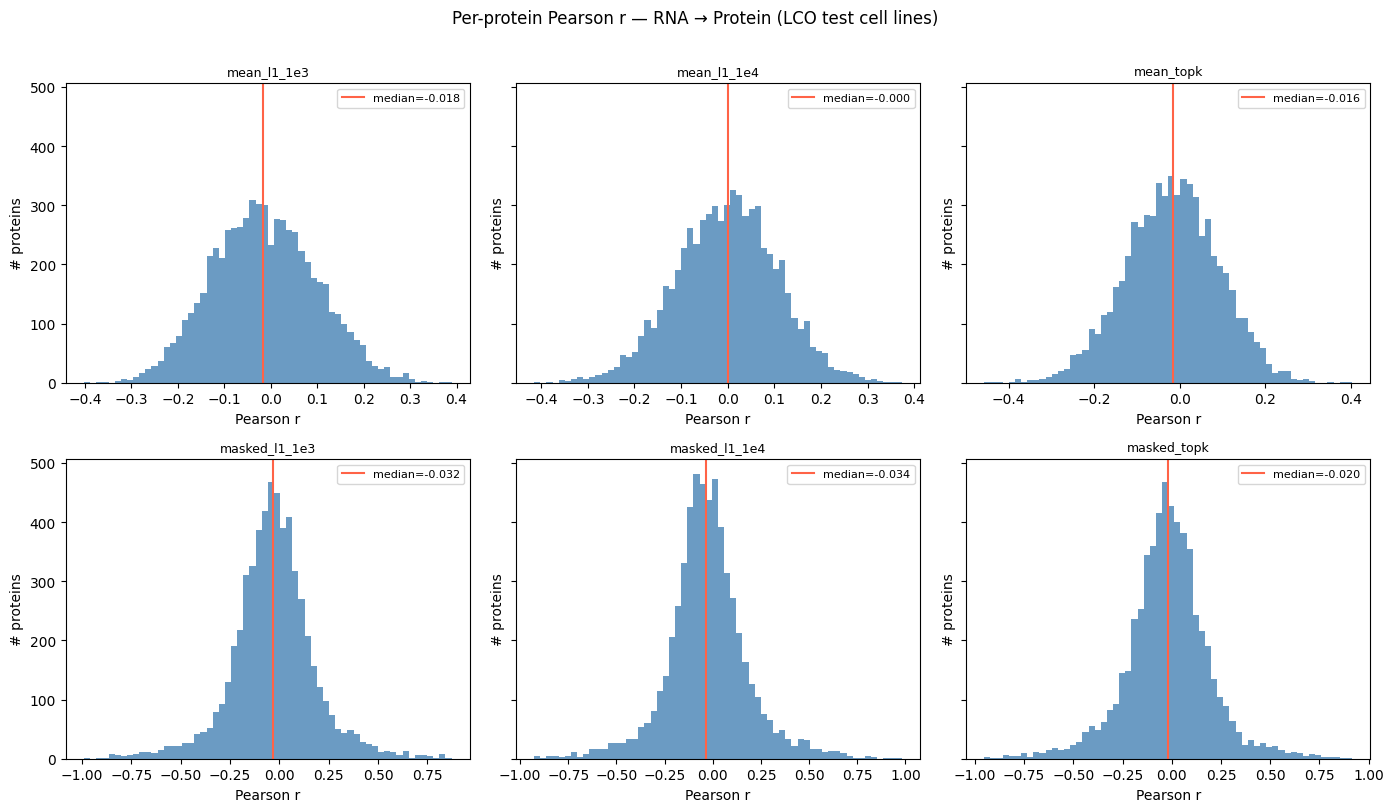

In [70]:
arm_evals = {
    'mean_l1_1e3':   armA1_eval_df,
    'mean_l1_1e4':   armA2_eval_df,
    'mean_topk':     armA3_eval_df,
    'masked_l1_1e3': armB1_eval_df,
    'masked_l1_1e4': armB2_eval_df,
    'masked_topk':   armB3_eval_df,
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True)
for ax, (arm_name, df) in zip(axes.flat, arm_evals.items()):
    r_vals = df['pearson_r'].dropna()
    ax.hist(r_vals, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
    ax.axvline(r_vals.median(), color='tomato', linewidth=1.5,
               label=f'median={r_vals.median():.3f}')
    ax.set_title(arm_name, fontsize=9)
    ax.set_xlabel('Pearson r')
    ax.set_ylabel('# proteins')
    ax.legend(fontsize=8)

plt.suptitle('Per-protein Pearson r — RNA → Protein (LCO test cell lines)', y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'per_protein_pearsonr_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

## Learning curves

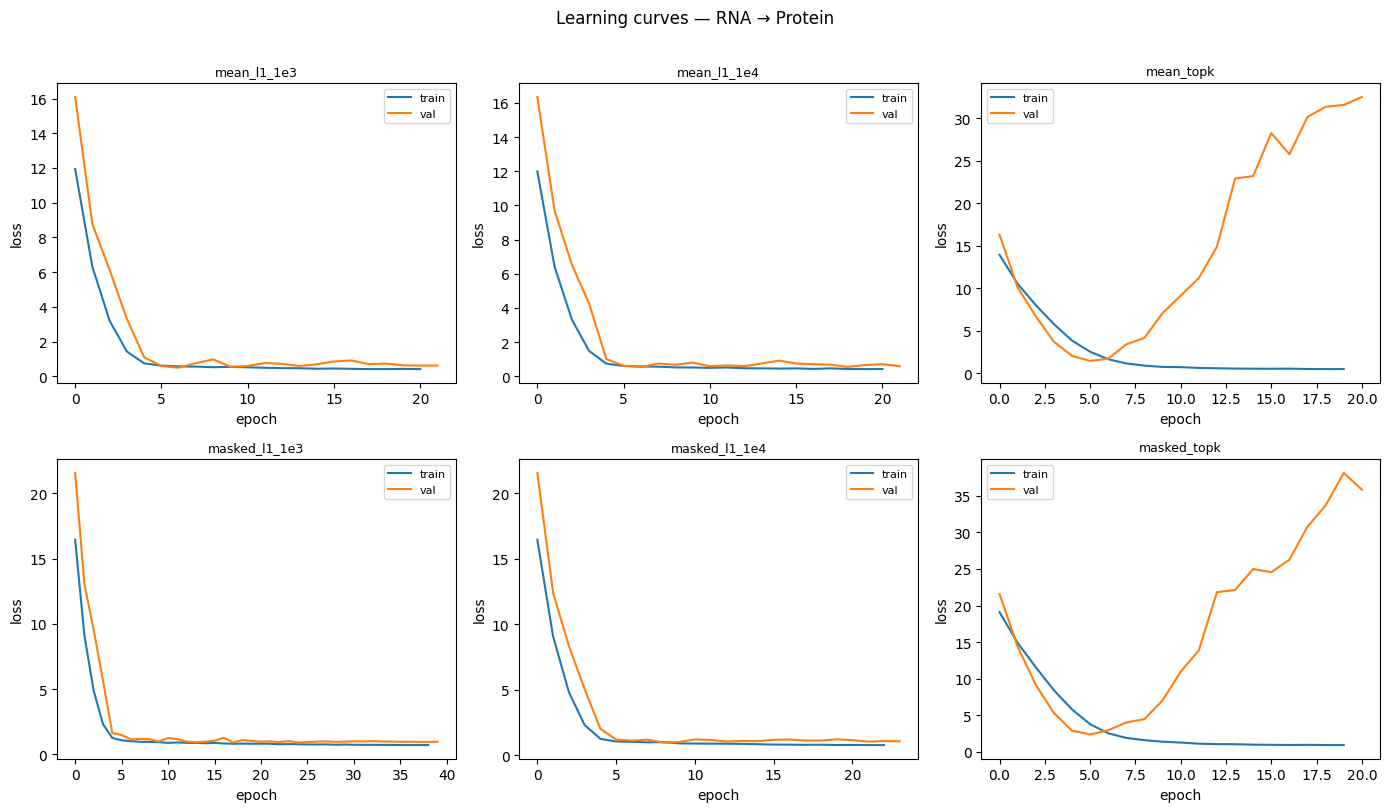

In [71]:
histories = {
    'mean_l1_1e3':   armA1_history,
    'mean_l1_1e4':   armA2_history,
    'mean_topk':     armA3_history,
    'masked_l1_1e3': armB1_history,
    'masked_l1_1e4': armB2_history,
    'masked_topk':   armB3_history,
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (arm_name, hist) in zip(axes.flat, histories.items()):
    ax.plot(hist['train_loss'], label='train')
    ax.plot(hist['val_loss'],   label='val')
    ax.set_title(arm_name, fontsize=9)
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.legend(fontsize=8)

plt.suptitle('Learning curves — RNA → Protein', y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## Top predicted proteins

Which proteins are best predicted by RNA across all arms? These are the genes
where RNA→protein coupling is strongest and the model learned it reliably.

In [72]:
# Use best arm (highest median Pearson r) for top protein analysis
best_arm_name = summary_df.iloc[0]['arm']
best_eval_df  = arm_evals[best_arm_name].sort_values('pearson_r', ascending=False)

print(f'Best arm: {best_arm_name}')
print(f'\nTop 20 best-predicted proteins:')
display(best_eval_df.head(20)[['protein', 'pearson_r', 'r2', 'n_observed']])

print(f'\nBottom 20 worst-predicted proteins (most independent of RNA):')
display(best_eval_df.tail(20)[['protein', 'pearson_r', 'r2', 'n_observed']])

Best arm: mean_l1_1e4

Top 20 best-predicted proteins:


,protein,pearson_r,r2,n_observed
3751,O60861;GAS7_HUMAN,0.372865,0.013790,84
4396,Q9BVC5;ASHWN_HUMAN,0.367707,-0.090745,84
2845,Q92734;TFG_HUMAN,0.347655,0.107264,84
5888,Q6P3X3;TTC27_HUMAN,0.347095,-45.948547,84
4139,Q9Y426;C2CD2_HUMAN,0.345073,-0.470199,84
5697,Q5VV41;ARHGG_HUMAN,0.326064,-0.514916,84
5897,Q6ZN66;GBP6_HUMAN,0.324264,-0.509977,84
4037,Q13228;SBP1_HUMAN,0.322038,0.098124,84
4547,Q9Y5T4;DJC15_HUMAN,0.319387,-0.733868,84
5577,Q9P021;CRIPT_HUMAN,0.317527,-0.157441,84



Bottom 20 worst-predicted proteins (most independent of RNA):


,protein,pearson_r,r2,n_observed
6523,P01303;NPY_HUMAN,NaN,-6.724704e+10,84
6528,P15172;MYOD1_HUMAN,NaN,0.000000e+00,84
6529,Q96JB2;COG3_HUMAN,NaN,0.000000e+00,84
6540,Q8NG06;TRI58_HUMAN,NaN,-1.037114e+12,84
6547,Q9UKN1;MUC12_HUMAN,NaN,-3.140608e+11,84
6561,Q96QU8;XPO6_HUMAN,NaN,0.000000e+00,84
6572,Q96R05;RET7_HUMAN,NaN,-6.147517e+11,84
6584,Q9UKY1;ZHX1_HUMAN,NaN,-8.331981e+11,84
6594,Q6GYQ0;RGPA1_HUMAN,NaN,-6.047734e+11,84
6596,Q9NYP3;DONS_HUMAN,NaN,-1.332155e+12,84


In [73]:
# Save best arm per-protein results with deviation flag
# deviation = protein is poorly predicted by RNA (Pearson r < 0.1)
# These are the candidates for post-transcriptional regulation
best_eval_df['high_deviation'] = best_eval_df['pearson_r'] < 0.1
best_eval_df.to_csv(RESULTS_DIR / f'best_arm_{best_arm_name}_per_protein_with_deviation.csv',
                    index=False)

n_high_dev = best_eval_df['high_deviation'].sum()
print(f'Proteins poorly predicted by RNA (r < 0.1): {n_high_dev:,} / {len(best_eval_df):,} '
      f'({n_high_dev/len(best_eval_df)*100:.1f}%)')
print('These are candidates for post-transcriptional regulation — input for nb16.')

Proteins poorly predicted by RNA (r < 0.1): 5,328 / 6,651 (80.1%)
These are candidates for post-transcriptional regulation — input for nb16.
